In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r'C:\Users\xys\Desktop\preprocessed_content.csv')

df = df.dropna(subset=["preprocessed_content"])
df["text"] = df["preprocessed_content"].astype(str).str.lower()

In [7]:
commit_words = [
    "commit", "aim", "target", "plan", "intend", "goal", "will"
]

action_words = [
    "implemented", "reduced", "achieved", "delivered",
    "installed", "completed", "decreased"
]
def count_words(text, words):
    return sum(text.count(w) for w in words)


def q2_score(text):
    c = count_words(text, commit_words)
    a = count_words(text, action_words)
    
    return c / (a + 1)
   

In [8]:
df["q2_inconsistency"] = df["text"].apply(q2_score)

In [9]:
top20 = df.sort_values("q2_inconsistency", ascending=False).head(20)
print(top20.head())

     Unnamed: 0           filename ticker  year  \
773         773  NYSE_TGT_2021.pdf    TGT  2021   
428         428  NYSE_COP_2022.pdf    COP  2022   
340         340  NYSE_AVY_2019.pdf    AVY  2019   
741         741  NYSE_SRE_2020.pdf    SRE  2020   
669         669  NYSE_PCG_2021.pdf    PCG  2021   

                                  preprocessed_content  \
773  target corporate responsibility report custom ...   
428  report social create share value work communit...   
340  make material difference integrate sustainabil...   
741  corporate sustainability report innovation sus...   
669  corporate sustainability report explore report...   

                                          ner_entities  e_score  s_score  \
773  ['over two decades', 'decades', 'u.s.', 'texas...     1.99     7.63   
428  ['year', 'ghg', 'our second decade', 'decades'...    17.45     9.71   
340  ['annual', 'avery dennison                    ...    13.30     1.58   
741  ['annual', 'u.n', 'oncor electric d

C:\Users\xys\AppData\Local\Temp\ipykernel_43572\1135633520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


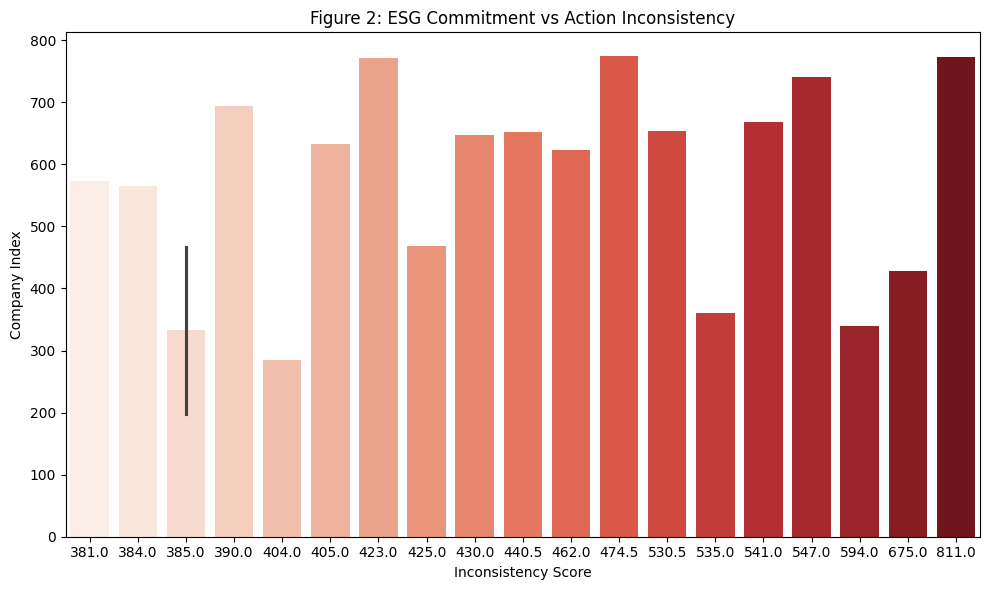

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x="q2_inconsistency",
    y=top20.index,
    palette="Reds"
)

plt.title("Figure 2: ESG Commitment vs Action Inconsistency")
plt.xlabel("Inconsistency Score")
plt.ylabel("Company Index")

plt.tight_layout()
plt.show()

In [11]:
df.head()

,Unnamed: 0,filename,ticker,year,preprocessed_content,ner_entities,e_score,s_score,g_score,total_score,text,q2_inconsistency
0,0,ASX_BSX_2020.pdf,BSX,2020,style guide colour colour use imagecolour prof...,"['bk%', 'rgb', 'un', 'el ectric mine consortiu...",3.16,18.00,11.83,32.98,style guide colour colour use imagecolour prof...,96.0
1,1,ASX_BSX_2022.pdf,BSX,2022,sustainability report look mining green office...,"['murray street', 'west perth', 'west perth', ...",2.83,12.86,10.32,26.02,sustainability report look mining green office...,90.0
2,2,ASX_EXR_2022.pdf,EXR,2022,report environment social governance esg basel...,"['september', 'mongolia', 'australia', 'austra...",3.81,4.28,5.86,13.94,report environment social governance esg basel...,28.0
3,3,LSE_ADM_2019.pdf,ADM,2019,corporate social responsibilty report introduc...,"['david stevens', 'csr board', 'just over yea...",16.38,14.20,5.90,36.36,corporate social responsibilty report introduc...,50.0
4,4,LSE_ADM_2020.pdf,ADM,2020,sustainability admiral commit maintain respons...,"['year', 'health & wellbeing', 'a -month', 'on...",15.89,13.51,5.38,34.78,sustainability admiral commit maintain respons...,79.0


In [12]:
import re

In [13]:
def specificity_score(text):
    text = str(text).lower()
    
    q = len(re.findall(r"\d+%|\d+\s*(tons|kg|co2|kwh|mw|million|billion)", text))
    n = len(re.findall(r"net zero|carbon neutral|reduce emissions|climate goal|by 20\d{2}", text))
    t = len(re.findall(r"by 20\d{2}|within \d+ years", text))
    
    w = len(text.split())
    if w == 0:
        return 0
    
    return (q + n + t) / w * 1000

In [14]:
def intensity(text):
    text = str(text).lower()
    keywords = ["environment", "climate", "emission", "carbon", "sustainability"]
    
    return sum(text.count(k) for k in keywords) / len(text.split())

In [15]:
df["specificity"] = df["text"].apply(specificity_score)
df["intensity"] = df["text"].apply(intensity)

In [16]:
df[["specificity","intensity"]].head()

,specificity,intensity
0,0.000000,0.014578
1,0.000000,0.017670
2,0.000000,0.015759
3,0.000000,0.014317
4,0.585594,0.020691


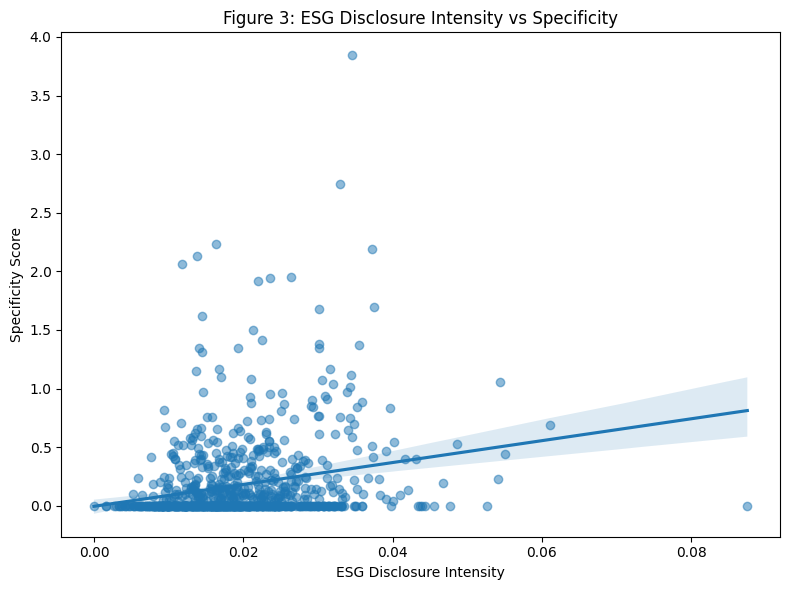

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="intensity",
    y="specificity",
    scatter_kws={"alpha":0.5}
)

plt.title("Figure 3: ESG Disclosure Intensity vs Specificity")
plt.xlabel("ESG Disclosure Intensity")
plt.ylabel("Specificity Score")

plt.tight_layout()
plt.show()